<a href="https://colab.research.google.com/github/kalpanareddy3/Dissertation-Code/blob/main/LD7083_Chapter4_Results_Analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Results and Analysis
## Detecting Fake Product Reviews Using Review Text and Rating Patterns
### LD7083 – MSc Computing and Digital Technologies Project Dissertation

---


## STEP 1: Install & Import Required Libraries

In [ ]:
# Install any missing libraries
!pip install wordcloud textblob gensim scipy --quiet

import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix
from scipy import stats

from wordcloud import WordCloud
from textblob import TextBlob

print("All libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.7 MB/s eta 0:00:00
All libraries imported successfully.


## STEP 2: Load Dataset and Basic Overview

In [ ]:
# ==============================
# LOAD DATASET
# ==============================
# If running on Google Colab, uncomment the block below to upload the file:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv("fake_reviews_dataset.csv")

# Load the dataset (update path if necessary)
df = pd.read_csv("/content/fake reviews dataset.csv")

print("Dataset loaded successfully!")
print("\nDataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:", df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary of numerical columns:")
display(df.describe())

print("\nMissing values in each column:")
display(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
display(df['label'].value_counts())

print("\nRating distribution:")
display(df['rating'].value_counts().sort_index())

print("\nProduct category distribution:")
display(df['category'].value_counts())

Dataset loaded successfully!

Dataset shape: (40432, 4)

First 5 rows:


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...



Column names: ['category', 'rating', 'label', 'text_']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB

Statistical summary of numerical columns:


,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000



Missing values in each column:


...

,count
label,
CG,20216
OR,20216



Rating distribution:


,count
rating,
1.0,2155
2.0,1967
3.0,3786
4.0,7965
5.0,24559



Product category distribution:


,count
category,
Kindle_Store_5,4730
Books_5,4370
Pet_Supplies_5,4254
Home_and_Kitchen_5,4056
Electronics_5,3988
Sports_and_Outdoors_5,3946
Tools_and_Home_Improvement_5,3858
Clothing_Shoes_and_Jewelry_5,3848
Toys_and_Games_5,3794


## STEP 3: Data Cleaning and Pre-processing

In [ ]:
# ==============================
# DATA CLEANING
# ==============================

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())

# Enforce correct data types
df['text_']    = df['text_'].astype(str)
df['category'] = df['category'].astype(str)
df['label']    = df['label'].astype(str)
df['rating']   = df['rating'].astype(float)

# Validate rating range
print("\nRating range check (should be 1–5):")
print("Min rating:", df['rating'].min(), "| Max rating:", df['rating'].max())

# Add basic text length features
df['review_length'] = df['text_'].apply(len)
df['word_count']    = df['text_'].apply(lambda x: len(x.split()))

# Encode labels: OR=0 (Genuine), CG=1 (Fake/Computer-Generated)
df['label_encoded'] = df['label'].map({'OR': 0, 'CG': 1})

print("\nLabel encoding:")
print("OR = 0 = Genuine (Original) Review")
print("CG = 1 = Fake (Computer-Generated) Review")
display(df['label'].value_counts())

print("\nDataset preview after initial cleaning:")
display(df.head())

Dataset shape after removing duplicates: (40420, 4)
Duplicate rows after cleaning: 0

Rating range check (should be 1–5):
Min rating: 1.0 | Max rating: 5.0

Label encoding:
OR = 0 = Genuine (Original) Review
CG = 1 = Fake (Computer-Generated) Review


,count
label,
OR,20215
CG,20205



Dataset preview after initial cleaning:


,category,rating,label,text_,review_length,word_count,label_encoded
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor...",75,12,1
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I...",80,16,1
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...,67,14,1
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i...",81,17,1
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...,85,18,1


## FIGURE 4.1: Distribution of Fake vs Genuine Reviews

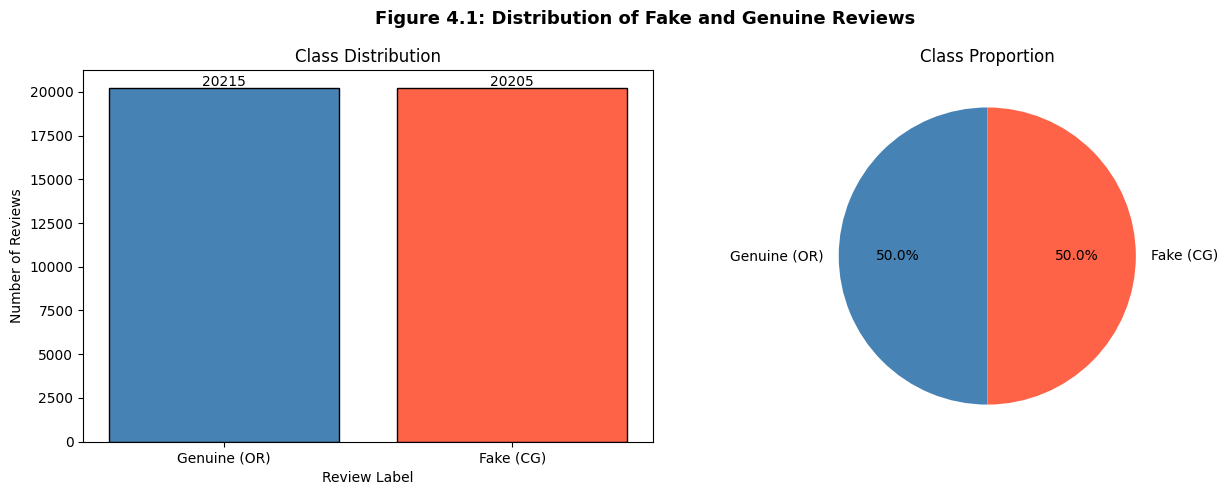

Label counts:


,count
label,
OR,20215
CG,20205



Label distribution (%):


,proportion
label,
OR,50.01
CG,49.99


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
counts = df['label'].value_counts()
bars = axes[0].bar(['Genuine (OR)', 'Fake (CG)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(int(bar.get_height())), ha='center', fontsize=10)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xlabel("Review Label")

# Pie chart
axes[1].pie(counts.values, labels=['Genuine (OR)', 'Fake (CG)'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title("Class Proportion")

plt.suptitle("Figure 4.1: Distribution of Fake and Genuine Reviews", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_1_Class_Distribution.png", dpi=300)
plt.show()

print("Label counts:")
display(df['label'].value_counts())
print("\nLabel distribution (%):")
display((df['label'].value_counts(normalize=True) * 100).round(2))

## FIGURE 4.2: Rating Distribution Patterns by Label

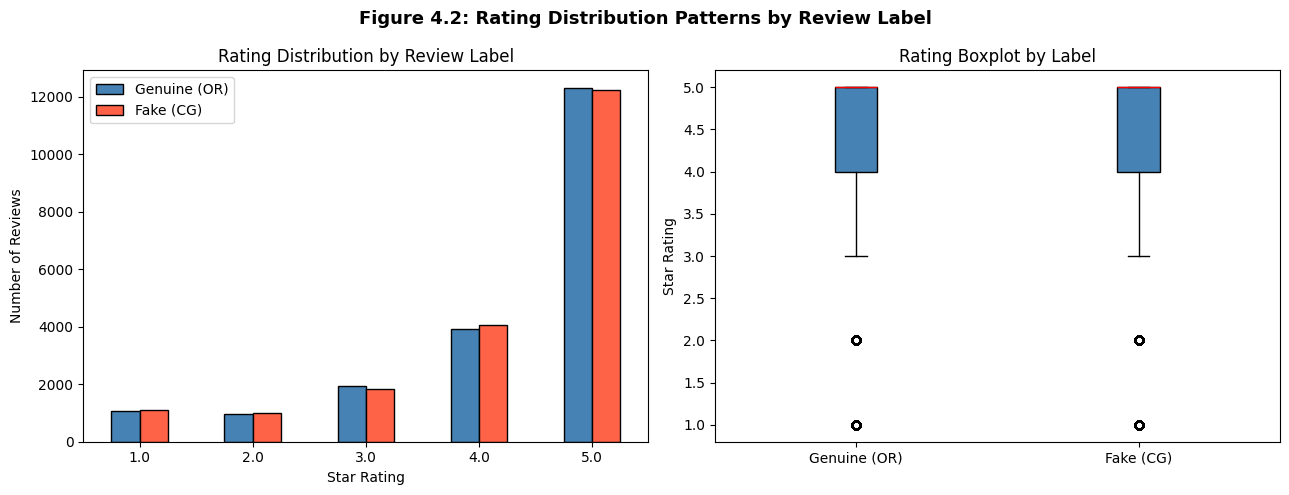


Rating distribution by label (counts):


label,CG,OR,All
rating,,,
1.0,1063,1092,2155
2.0,962,1005,1967
3.0,1952,1834,3786
4.0,3920,4045,7965
5.0,12308,12239,24547
All,20205,20215,40420



Mean rating by label:
label
CG    4.259
OR    4.253
Name: rating, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rating distribution grouped by label
rating_label = pd.crosstab(df['rating'], df['label'])
rating_label.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title("Rating Distribution by Review Label")
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Genuine (OR)', 'Fake (CG)'])

# Boxplot of ratings by label
fake_ratings    = df[df['label'] == 'CG']['rating']
genuine_ratings = df[df['label'] == 'OR']['rating']
axes[1].boxplot([genuine_ratings, fake_ratings], labels=['Genuine (OR)', 'Fake (CG)'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                medianprops=dict(color='red'))
axes[1].set_title("Rating Boxplot by Label")
axes[1].set_ylabel("Star Rating")

plt.suptitle("Figure 4.2: Rating Distribution Patterns by Review Label", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_2_Rating_Distribution.png", dpi=300)
plt.show()

print("\nRating distribution by label (counts):")
display(pd.crosstab(df['rating'], df['label'], margins=True))

print("\nMean rating by label:")
print(df.groupby('label')['rating'].mean().round(3))

## STEP 4: Text Preprocessing (Tokenisation, Stop-word Removal, Lemmatisation)

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Full NLP preprocessing pipeline: lowercase, remove noise,
    tokenise, remove stop words, lemmatise."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"<.*?>", "", text)                  # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)            # keep only letters
    text = re.sub(r"\s+", " ", text).strip()           # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

df['cleaned_text']       = df['text_'].apply(clean_text)
df['cleaned_word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print("Text preprocessing complete.")
print("\nPreprocessing examples (before vs after):")
display(df[['text_', 'cleaned_text']].head(5))

Text preprocessing complete.

Preprocessing examples (before vs after):


,text_,cleaned_text
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",love great upgrade original ive mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


## FIGURE 4.3: Text Preprocessing Output

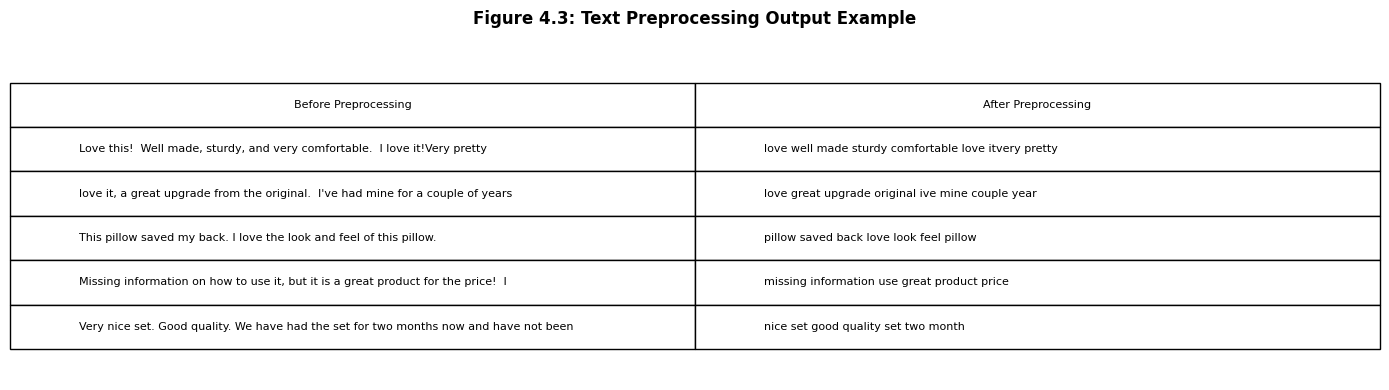

In [ ]:
example = df[['text_', 'cleaned_text']].head(5).copy()
example.columns = ['Before Preprocessing', 'After Preprocessing']

# Truncate long strings for table display
example['Before Preprocessing'] = example['Before Preprocessing'].apply(lambda x: x[:120] + '...' if len(x) > 120 else x)
example['After Preprocessing']  = example['After Preprocessing'].apply(lambda x: x[:120] + '...' if len(x) > 120 else x)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText=example.values,
    colLabels=example.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.5)
plt.title("Figure 4.3: Text Preprocessing Output Example", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("Figure_4_3_Text_Preprocessing_Output.png", dpi=300, bbox_inches='tight')
plt.show()

## FIGURE 4.4: Word Cloud Comparison — Fake vs Genuine Reviews

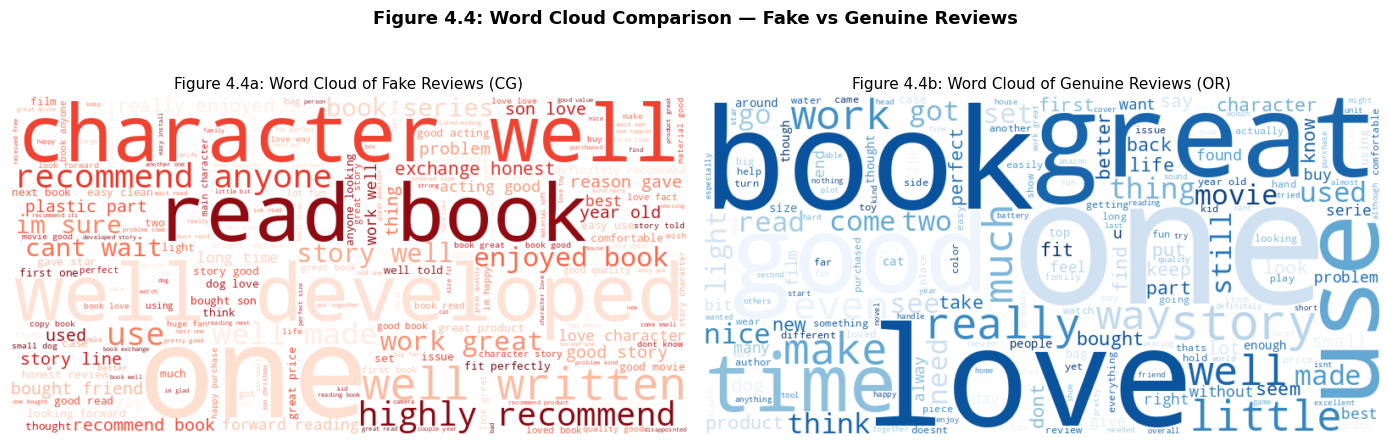

In [ ]:
fake_text    = " ".join(df[df['label'] == 'CG']['cleaned_text'])
genuine_text = " ".join(df[df['label'] == 'OR']['cleaned_text'])

fake_wc    = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)
genuine_wc = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(genuine_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(fake_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Figure 4.4a: Word Cloud of Fake Reviews (CG)", fontsize=11)

axes[1].imshow(genuine_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Figure 4.4b: Word Cloud of Genuine Reviews (OR)", fontsize=11)

plt.suptitle("Figure 4.4: Word Cloud Comparison — Fake vs Genuine Reviews", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_4_Wordcloud_Comparison.png", dpi=300)
plt.show()

## STEP 5: Linguistic Feature Engineering
### 5a. Lexical Diversity and Review Length Analysis (Objective 4)

In [ ]:
# ==============================
# LEXICAL DIVERSITY (Type-Token Ratio)
# A key indicator from the literature: fake reviews show lower lexical diversity
# ==============================

def lexical_diversity(text):
    """Type-Token Ratio: ratio of unique words to total words."""
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df['lexical_diversity'] = df['cleaned_text'].apply(lexical_diversity)

print("Lexical Diversity (Type-Token Ratio) by Label:")
display(df.groupby('label')['lexical_diversity'].describe().round(4))

Lexical Diversity (Type-Token Ratio) by Label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20205.0,0.8503,0.1547,0.0000,0.7692,0.8750,1.0,1.0
OR,20215.0,0.9098,0.0874,0.2941,0.8511,0.9231,1.0,1.0


### 5b. Sentiment Polarity Analysis (Objective 3)

In [ ]:
# ==============================
# SENTIMENT ANALYSIS
# Research question: Do fake reviews exhibit more extreme sentiment?
# ==============================

def get_sentiment_polarity(text):
    """Returns TextBlob sentiment polarity: -1 (negative) to +1 (positive)."""
    return TextBlob(text).sentiment.polarity

def get_sentiment_subjectivity(text):
    """Returns TextBlob sentiment subjectivity: 0 (objective) to 1 (subjective)."""
    return TextBlob(text).sentiment.subjectivity

print("Computing sentiment scores (this may take a few minutes)...")
df['sentiment_polarity']     = df['text_'].apply(get_sentiment_polarity)
df['sentiment_subjectivity'] = df['text_'].apply(get_sentiment_subjectivity)

print("\nSentiment polarity by label:")
display(df.groupby('label')['sentiment_polarity'].describe().round(4))

print("\nSentiment subjectivity by label:")
display(df.groupby('label')['sentiment_subjectivity'].describe().round(4))

Computing sentiment scores (this may take a few minutes)...

Sentiment polarity by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20205.0,0.2767,0.2329,-1.0,0.1295,0.2833,0.4250,1.0
OR,20215.0,0.2482,0.2315,-1.0,0.1061,0.2311,0.3781,1.0



Sentiment subjectivity by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20205.0,0.5697,0.1807,0.0,0.4850,0.5788,0.675,1.0
OR,20215.0,0.5433,0.1697,0.0,0.4522,0.5417,0.640,1.0


## FIGURE 4.5: Linguistic Feature Comparison — Fake vs Genuine Reviews

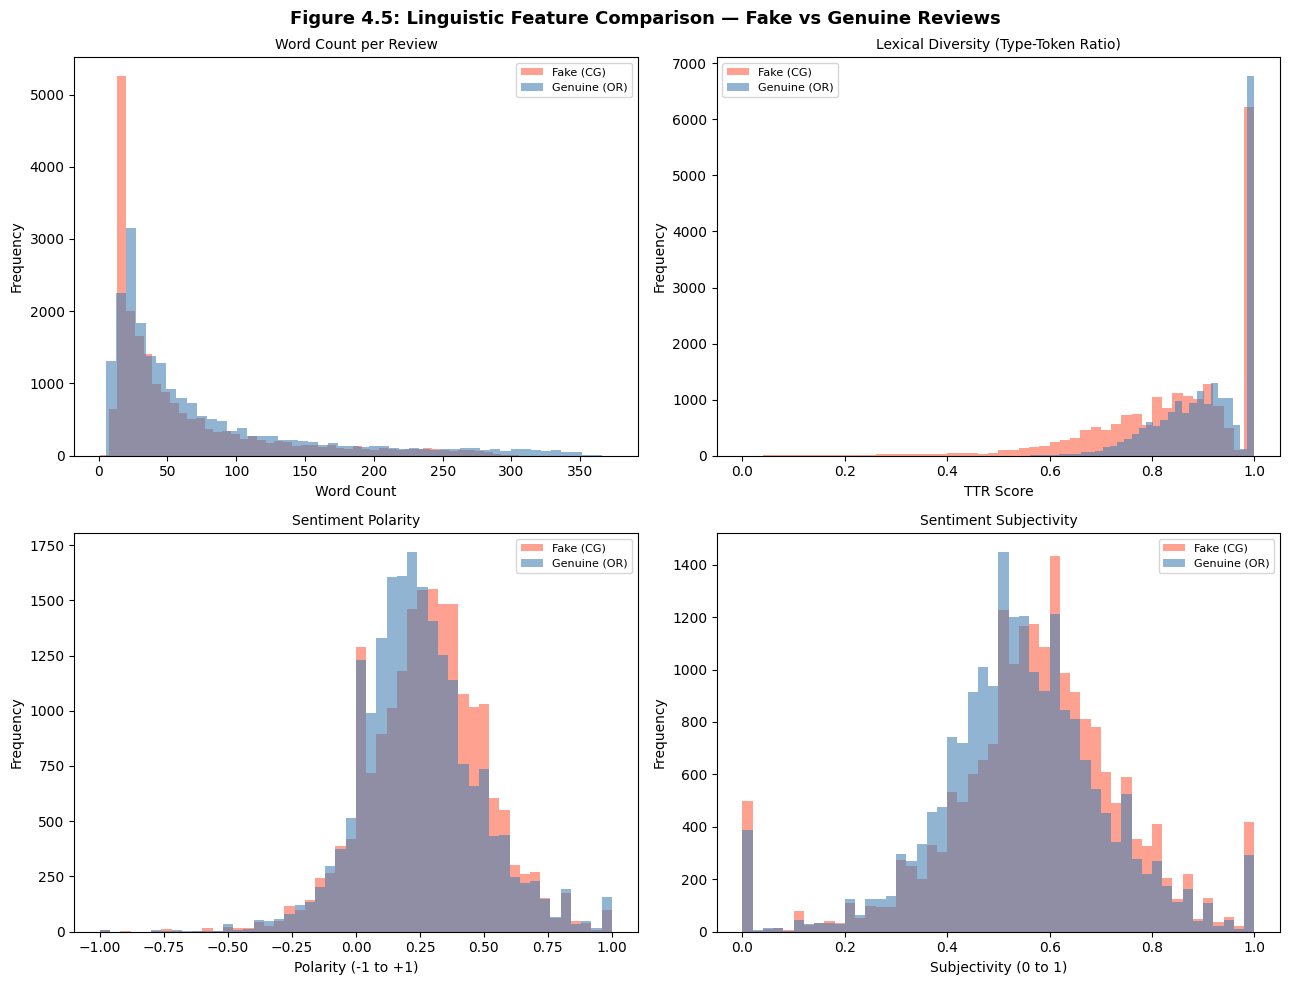


Summary of linguistic features by label:


,word_count,lexical_diversity,sentiment_polarity,sentiment_subjectivity
label,,,,
CG,61.3030,0.8503,0.2767,0.5697
OR,73.6431,0.9098,0.2482,0.5433


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

features = [
    ('word_count',             'Word Count per Review',              'Word Count'),
    ('lexical_diversity',      'Lexical Diversity (Type-Token Ratio)', 'TTR Score'),
    ('sentiment_polarity',     'Sentiment Polarity',                  'Polarity (-1 to +1)'),
    ('sentiment_subjectivity', 'Sentiment Subjectivity',              'Subjectivity (0 to 1)'),
]

for ax, (feat, title, xlabel) in zip(axes.flat, features):
    ax.hist(df[df['label']=='CG'][feat], bins=50, alpha=0.6, label='Fake (CG)', color='tomato')
    ax.hist(df[df['label']=='OR'][feat], bins=50, alpha=0.6, label='Genuine (OR)', color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Figure 4.5: Linguistic Feature Comparison — Fake vs Genuine Reviews",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_5_Linguistic_Feature_Comparison.png", dpi=300)
plt.show()

print("\nSummary of linguistic features by label:")
display(df.groupby('label')[['word_count','lexical_diversity','sentiment_polarity','sentiment_subjectivity']].mean().round(4))

## STEP 6: Statistical Significance Testing (Objective 5)
### Testing whether linguistic differences between fake and genuine reviews are statistically significant

In [ ]:
# ==============================
# STATISTICAL SIGNIFICANCE TESTS
# Mann-Whitney U test used (non-parametric, suitable for non-normal distributions)
# H0: No significant difference between fake and genuine review features
# ==============================

fake_df    = df[df['label'] == 'CG']
genuine_df = df[df['label'] == 'OR']

features_to_test = [
    ('word_count',             'Word Count'),
    ('lexical_diversity',      'Lexical Diversity (TTR)'),
    ('sentiment_polarity',     'Sentiment Polarity'),
    ('sentiment_subjectivity', 'Sentiment Subjectivity'),
    ('rating',                 'Star Rating'),
]

stat_results = []
for col, label in features_to_test:
    stat, p = stats.mannwhitneyu(fake_df[col], genuine_df[col], alternative='two-sided')
    stat_results.append({
        'Feature':             label,
        'Mean (Fake)':         fake_df[col].mean().round(4),
        'Mean (Genuine)':      genuine_df[col].mean().round(4),
        'Mann-Whitney U':      round(stat, 2),
        'p-value':             round(p, 6),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stat_results)

print("Table 4.2: Statistical Significance of Linguistic and Rating Differences")
print("(Mann-Whitney U Test, two-sided, alpha=0.05)")
display(stat_df)
stat_df.to_csv("Table_4_2_Statistical_Significance.csv", index=False)

print("\nInterpretation: A p-value < 0.05 indicates the feature differs",
      "significantly between fake and genuine reviews.")

Table 4.2: Statistical Significance of Linguistic and Rating Differences
(Mann-Whitney U Test, two-sided, alpha=0.05)


,Feature,Mean (Fake),Mean (Genuine),Mann-Whitney U,p-value,Significant (p<0.05)
0,Word Count,61.3030,73.6431,185311952.0,0.000000,Yes
1,Lexical Diversity (TTR),0.8503,0.9098,163747552.5,0.000000,Yes
2,Sentiment Polarity,0.2767,0.2482,223871526.5,0.000000,Yes
3,Sentiment Subjectivity,0.5697,0.5433,228398025.5,0.000000,Yes
4,Star Rating,4.2595,4.2532,204822769.0,0.558758,No



Interpretation: A p-value < 0.05 indicates the feature differs significantly between fake and genuine reviews.


## STEP 7: Rating-Text Inconsistency Feature Engineering (Objective 4)

In [ ]:
# ==============================
# RATING-TEXT INCONSISTENCY
# Literature states fake reviews often show inconsistency between
# the numeric star rating and the textual sentiment expressed.
# ==============================

def expected_rating_from_sentiment(polarity):
    """Map sentiment polarity to an expected 1–5 star rating."""
    if polarity >= 0.5:  return 5
    elif polarity >= 0.1: return 4
    elif polarity >= -0.1: return 3
    elif polarity >= -0.5: return 2
    else: return 1

df['expected_rating']   = df['sentiment_polarity'].apply(expected_rating_from_sentiment)
df['rating_text_gap']   = abs(df['rating'] - df['expected_rating'])
df['rating_inconsistent'] = (df['rating_text_gap'] >= 2).astype(int)  # flag large inconsistencies

print("Rating-text inconsistency by label:")
display(df.groupby('label')[['rating_text_gap', 'rating_inconsistent']].mean().round(4))

print("\nProportion of highly inconsistent reviews (gap >= 2 stars):")
display((df.groupby('label')['rating_inconsistent'].mean() * 100).round(2).rename("% Inconsistent"))

Rating-text inconsistency by label:


,rating_text_gap,rating_inconsistent
label,,
CG,1.0017,0.2093
OR,0.9095,0.1648



Proportion of highly inconsistent reviews (gap >= 2 stars):


,% Inconsistent
label,
CG,20.93
OR,16.48


## FIGURE 4.6: Rating-Text Inconsistency Analysis

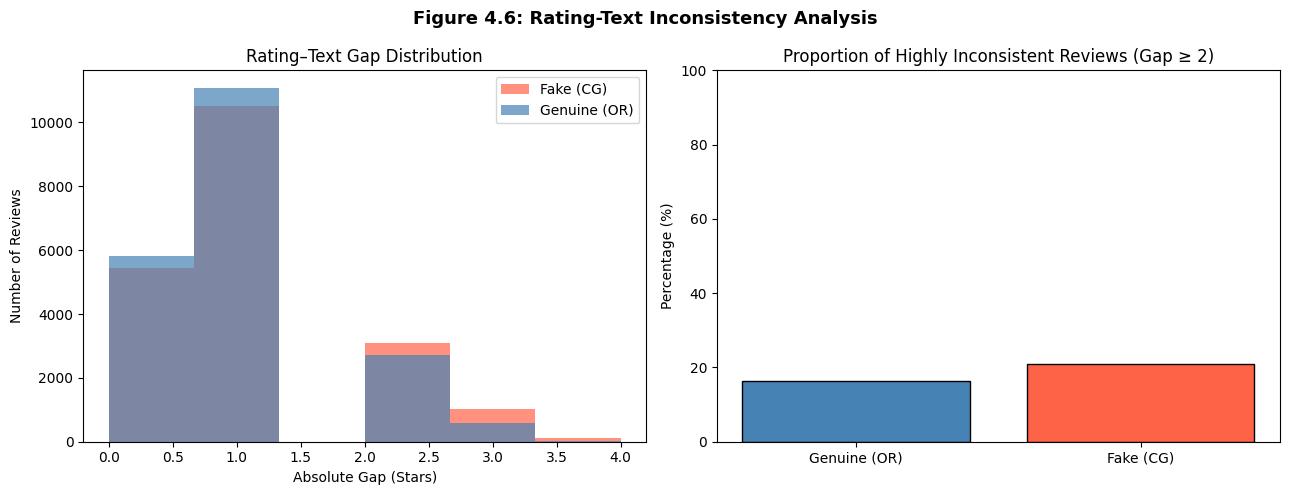

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of rating-text gap
axes[0].hist(df[df['label']=='CG']['rating_text_gap'], bins=6, alpha=0.7, label='Fake (CG)', color='tomato')
axes[0].hist(df[df['label']=='OR']['rating_text_gap'], bins=6, alpha=0.7, label='Genuine (OR)', color='steelblue')
axes[0].set_title("Rating–Text Gap Distribution")
axes[0].set_xlabel("Absolute Gap (Stars)")
axes[0].set_ylabel("Number of Reviews")
axes[0].legend()

# Proportion of inconsistent reviews by label
incon_pct = df.groupby('label')['rating_inconsistent'].mean() * 100
axes[1].bar(['Genuine (OR)', 'Fake (CG)'],
            [incon_pct.get('OR', 0), incon_pct.get('CG', 0)],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title("Proportion of Highly Inconsistent Reviews (Gap ≥ 2)")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)

plt.suptitle("Figure 4.6: Rating-Text Inconsistency Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_6_Rating_Text_Inconsistency.png", dpi=300)
plt.show()

## STEP 8: TF-IDF Feature Extraction (Objective 3)

In [ ]:
# ==============================
# TF-IDF VECTORISATION
# Unigrams + Bigrams (n-gram range 1–2)
# max_features=5000 to control dimensionality
# ==============================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_text = tfidf.fit_transform(df['cleaned_text'])
y      = df['label_encoded']

print("TF-IDF matrix shape:", X_text.shape)
print("(Rows = reviews, Columns = TF-IDF features)")

TF-IDF matrix shape: (40420, 5000)
(Rows = reviews, Columns = TF-IDF features)


## FIGURE 4.7: Top TF-IDF Features and N-gram Comparison

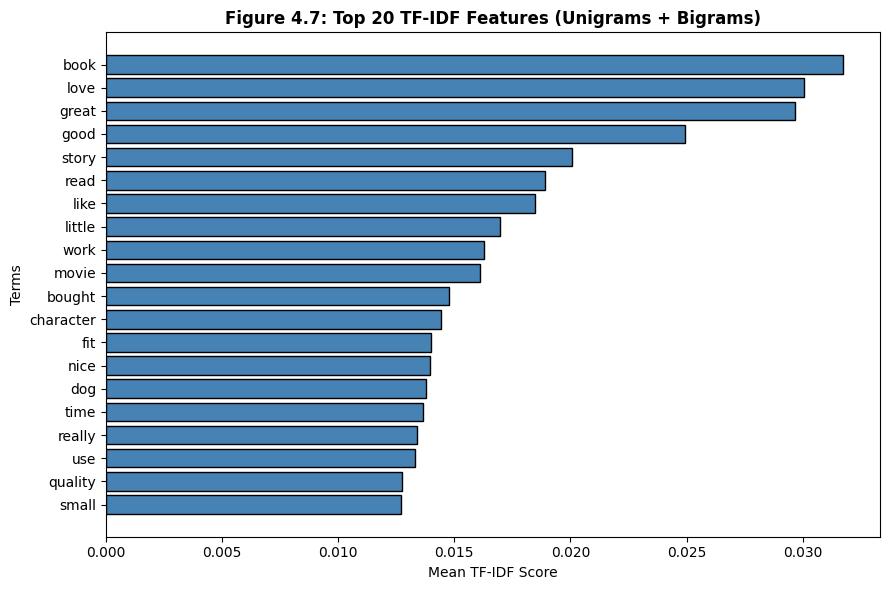


Top TF-IDF features table:


,TF-IDF Feature,Mean TF-IDF Score
0,book,0.031741
1,love,0.030058
2,great,0.029651
3,good,0.024938
4,story,0.020075
5,read,0.018889
6,like,0.018465
7,little,0.016959
8,work,0.016293
9,movie,0.016117


In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf    = np.asarray(X_text.mean(axis=0)).ravel()

top_n       = 20
top_indices = mean_tfidf.argsort()[-top_n:][::-1]
top_features = feature_names[top_indices]
top_scores   = mean_tfidf[top_indices]

plt.figure(figsize=(9, 6))
plt.barh(top_features[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
plt.title("Figure 4.7: Top 20 TF-IDF Features (Unigrams + Bigrams)", fontsize=12, fontweight='bold')
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Terms")
plt.tight_layout()
plt.savefig("Figure_4_7_Top_TFIDF_Features.png", dpi=300)
plt.show()

print("\nTop TF-IDF features table:")
display(pd.DataFrame({'TF-IDF Feature': top_features, 'Mean TF-IDF Score': top_scores.round(6)}))

## FIGURE 4.8: Top N-gram Frequency Comparison — Fake vs Genuine Reviews (Objective 3)

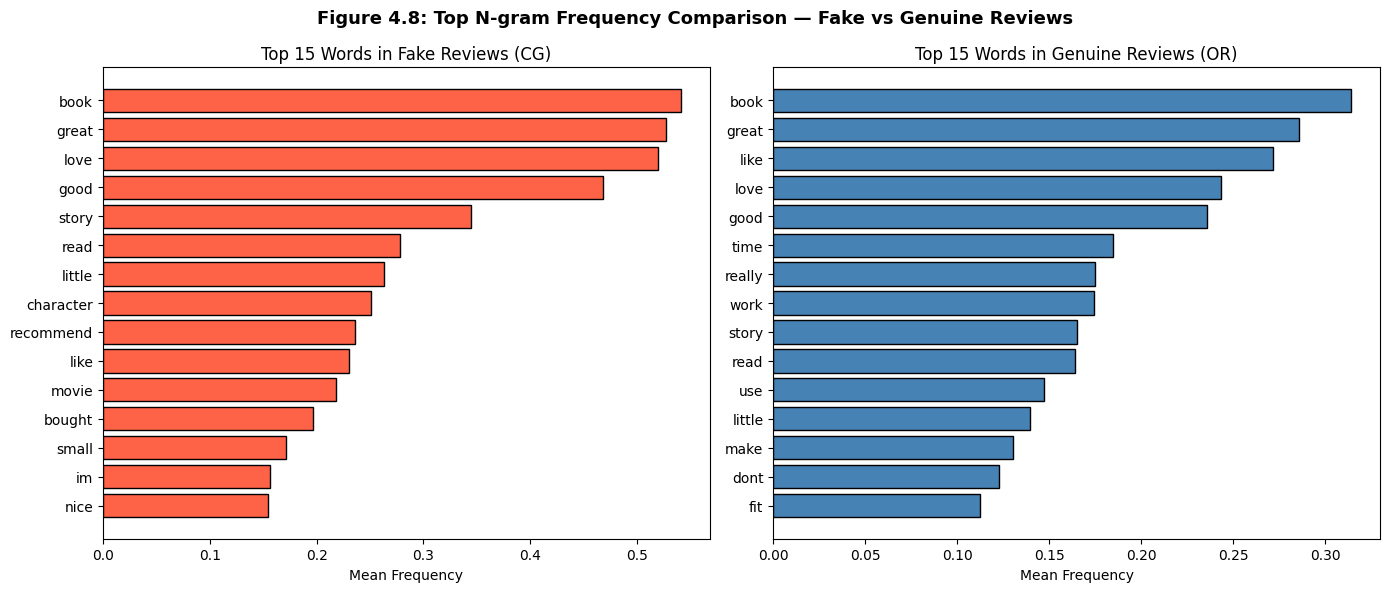

In [ ]:
# Compare top unigrams between fake and genuine reviews
cv = CountVectorizer(max_features=2000, ngram_range=(1,1), stop_words='english')

fake_counts    = cv.fit_transform(df[df['label']=='CG']['cleaned_text'])
genuine_counts = cv.transform(df[df['label']=='OR']['cleaned_text'])

vocab       = np.array(cv.get_feature_names_out())
fake_freq   = np.asarray(fake_counts.mean(axis=0)).ravel()
genuine_freq = np.asarray(genuine_counts.mean(axis=0)).ravel()

top_fake    = fake_freq.argsort()[-15:][::-1]
top_genuine = genuine_freq.argsort()[-15:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(vocab[top_fake][::-1], fake_freq[top_fake][::-1], color='tomato', edgecolor='black')
axes[0].set_title("Top 15 Words in Fake Reviews (CG)")
axes[0].set_xlabel("Mean Frequency")

axes[1].barh(vocab[top_genuine][::-1], genuine_freq[top_genuine][::-1], color='steelblue', edgecolor='black')
axes[1].set_title("Top 15 Words in Genuine Reviews (OR)")
axes[1].set_xlabel("Mean Frequency")

plt.suptitle("Figure 4.8: Top N-gram Frequency Comparison — Fake vs Genuine Reviews",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_8_Ngram_Comparison.png", dpi=300)
plt.show()

## STEP 9: Correlation Heatmap of All Numerical Features

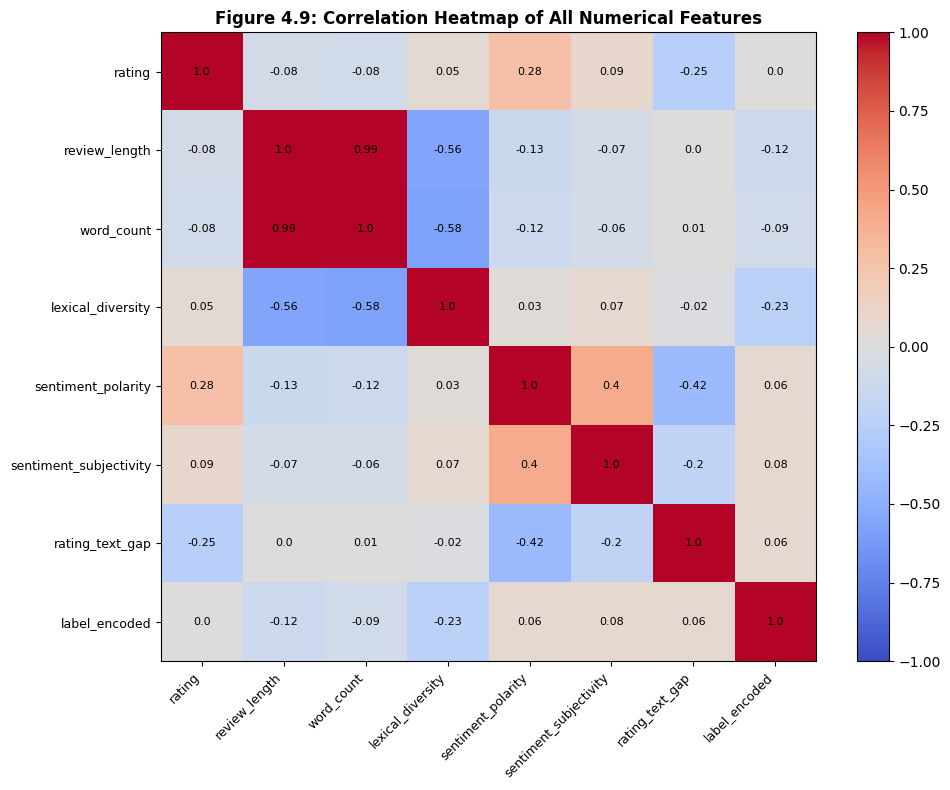

In [ ]:
corr_cols = ['rating', 'review_length', 'word_count', 'lexical_diversity',
             'sentiment_polarity', 'sentiment_subjectivity',
             'rating_text_gap', 'label_encoded']

corr_data = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_data, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(corr_cols)), corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, round(corr_data.iloc[i, j], 2), ha='center', va='center', fontsize=8)

plt.title("Figure 4.9: Correlation Heatmap of All Numerical Features",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_9_Correlation_Heatmap.png", dpi=300)
plt.show()

## STEP 10: Feature Set Construction — Text, Rating, Hybrid (Objective 7)

In [ ]:
# ==============================
# BUILD THREE FEATURE SETS:
# 1. Text-only (TF-IDF)
# 2. Rating-only (rating + review_length + word_count + lexical_diversity
#                 + sentiment_polarity + sentiment_subjectivity + rating_text_gap)
# 3. Hybrid (Text + Rating combined)
# ==============================

rating_feature_cols = [
    'rating', 'review_length', 'word_count',
    'lexical_diversity', 'sentiment_polarity',
    'sentiment_subjectivity', 'rating_text_gap'
]

scaler   = StandardScaler()
X_rating = scaler.fit_transform(df[rating_feature_cols])

X_rating_sparse = csr_matrix(X_rating)
X_hybrid        = hstack([X_text, X_rating_sparse])

print("Feature set shapes:")
print("  Text-only features:  ", X_text.shape)
print("  Rating-based features:", X_rating.shape)
print("  Hybrid features:      ", X_hybrid.shape)

Feature set shapes:
  Text-only features:   (40420, 5000)
  Rating-based features: (40420, 7)
  Hybrid features:       (40420, 5007)


## STEP 11: Train-Test Split (80/20)

In [ ]:
X_text_train,   X_text_test,   y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y)

X_rating_train, X_rating_test, _, _ = train_test_split(
    X_rating, y, test_size=0.2, random_state=42, stratify=y)

X_hybrid_train, X_hybrid_test, _, _ = train_test_split(
    X_hybrid, y, test_size=0.2, random_state=42, stratify=y)

print("Train-test split completed (80% train / 20% test):")
print("  Training records:", X_text_train.shape[0])
print("  Testing records: ", X_text_test.shape[0])
print("  Positive (fake) in test:", y_test.sum())
print("  Negative (genuine) in test:", (y_test == 0).sum())

Train-test split completed (80% train / 20% test):
  Training records: 32336
  Testing records:  8084
  Positive (fake) in test: 4041
  Negative (genuine) in test: 4043


## STEP 12: Model Training and Evaluation (Objectives 6, 7, 8)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, feature_type, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Feature Type": feature_type,
        "Model":        model_name,
        "Accuracy":     accuracy_score(y_test, y_pred),
        "Precision":    precision_score(y_test, y_pred, zero_division=0),
        "Recall":       recall_score(y_test, y_pred, zero_division=0),
        "F1-score":     f1_score(y_test, y_pred, zero_division=0),
        "Predictions":  y_pred,
        "Trained Model": model
    }

results = []
model_configs = [
    ("Text-only",   X_text_train,   X_text_test),
    ("Rating-only", X_rating_train, X_rating_test),
    ("Hybrid",      X_hybrid_train, X_hybrid_test),
]

for feat_type, X_tr, X_te in model_configs:
    print(f"Training models with {feat_type} features...")
    results.append(evaluate_model(LogisticRegression(max_iter=1000),
                                  X_tr, X_te, y_train, y_test, feat_type, "Logistic Regression"))
    results.append(evaluate_model(LinearSVC(max_iter=2000),
                                  X_tr, X_te, y_train, y_test, feat_type, "SVM"))
    results.append(evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                                  X_tr, X_te, y_train, y_test, feat_type, "Random Forest"))

print("All models trained successfully.")

Training models with Text-only features...
Training models with Rating-only features...
Training models with Hybrid features...
All models trained successfully.


## TABLE 4.1: Model Performance Comparison (Objective 8)

In [ ]:
results_df = pd.DataFrame(results).drop(columns=['Predictions', 'Trained Model'])
results_df[['Accuracy','Precision','Recall','F1-score']] = \
    results_df[['Accuracy','Precision','Recall','F1-score']].round(4)

print("Table 4.1: Model Performance Comparison — Text-only vs Rating-only vs Hybrid Features")
display(results_df)
results_df.to_csv("Table_4_1_Model_Performance_Comparison.csv", index=False)

Table 4.1: Model Performance Comparison — Text-only vs Rating-only vs Hybrid Features


,Feature Type,Model,Accuracy,Precision,Recall,F1-score
0,Text-only,Logistic Regression,0.8774,0.8841,0.8686,0.8763
1,Text-only,SVM,0.8837,0.8854,0.8815,0.8834
2,Text-only,Random Forest,0.8407,0.8502,0.8270,0.8384
3,Rating-only,Logistic Regression,0.7027,0.7116,0.6815,0.6962
4,Rating-only,SVM,0.7013,0.7132,0.6731,0.6926
5,Rating-only,Random Forest,0.7423,0.7437,0.7394,0.7415
6,Hybrid,Logistic Regression,0.8920,0.8982,0.8842,0.8911
7,Hybrid,SVM,0.8956,0.8964,0.8946,0.8955
8,Hybrid,Random Forest,0.8788,0.8858,0.8696,0.8776


## FIGURE 4.10: Model Performance Comparison Chart

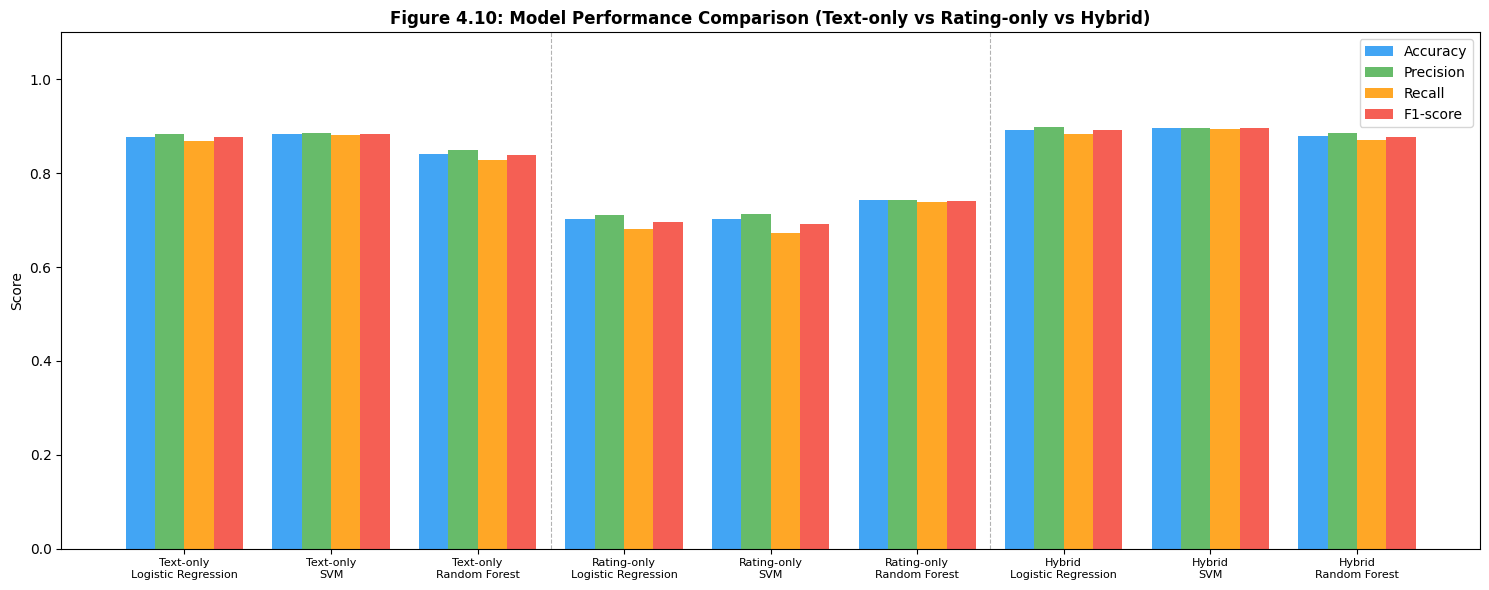

In [ ]:
plot_df = results_df.copy()
plot_df['Model Setup'] = plot_df['Feature Type'] + "\n" + plot_df['Model']

x     = np.arange(len(plot_df))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

plt.figure(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1-score'], colors)):
    plt.bar(x + (i - 1.5) * width, plot_df[metric], width, label=metric, color=color, alpha=0.85)

plt.xticks(x, plot_df['Model Setup'], fontsize=8)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Figure 4.10: Model Performance Comparison (Text-only vs Rating-only vs Hybrid)",
          fontsize=12, fontweight='bold')
plt.legend(loc='upper right')

# Add vertical separators between feature groups
for sep in [2.5, 5.5]:
    plt.axvline(x=sep, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig("Figure_4_10_Model_Performance_Comparison.png", dpi=300)
plt.show()

## STEP 13: Best Model Identification and Confusion Matrix (Objective 8)

In [ ]:
best_index  = results_df['F1-score'].idxmax()
best_result = results[best_index]
best_y_pred = best_result["Predictions"]

print("Best Performing Model (by F1-score):")
print(f"  Feature Type: {best_result['Feature Type']}")
print(f"  Model:        {best_result['Model']}")
print(f"  Accuracy:     {best_result['Accuracy']:.4f}")
print(f"  Precision:    {best_result['Precision']:.4f}")
print(f"  Recall:       {best_result['Recall']:.4f}")
print(f"  F1-score:     {best_result['F1-score']:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, best_y_pred,
                             target_names=["Genuine Review (OR)", "Fake Review (CG)"]))

Best Performing Model (by F1-score):
  Feature Type: Hybrid
  Model:        SVM
  Accuracy:     0.8956
  Precision:    0.8964
  Recall:       0.8946
  F1-score:     0.8955

Detailed Classification Report:
                     precision    recall  f1-score   support

Genuine Review (OR)       0.89      0.90      0.90      4043
   Fake Review (CG)       0.90      0.89      0.90      4041

           accuracy                           0.90      8084
          macro avg       0.90      0.90      0.90      8084
       weighted avg       0.90      0.90      0.90      8084



## FIGURE 4.11: Confusion Matrix of Best Model

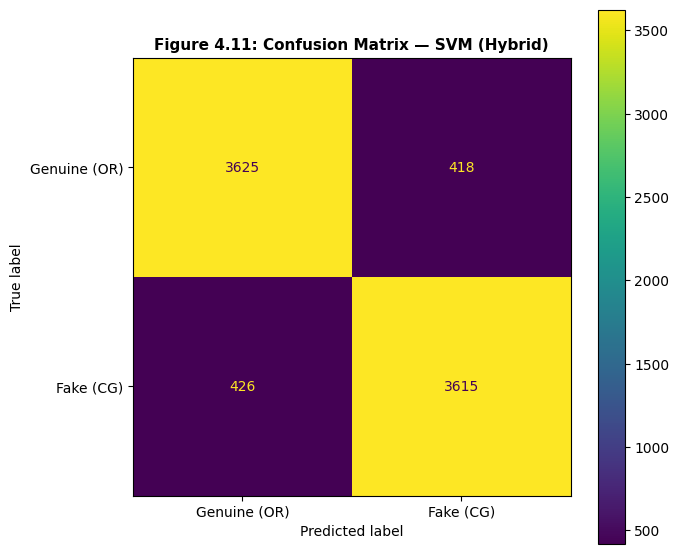

True Positives (fake correctly identified):  3615
True Negatives (genuine correctly identified): 3625
False Positives (genuine misclassified as fake): 418
False Negatives (fake misclassified as genuine): 426


In [ ]:
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine (OR)", "Fake (CG)"]
)
disp.plot(ax=ax, values_format='d', colorbar=True)
ax.set_title(
    f"Figure 4.11: Confusion Matrix — {best_result['Model']} ({best_result['Feature Type']})",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig("Figure_4_11_Confusion_Matrix_Best_Model.png", dpi=300)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fake correctly identified):  {tp}")
print(f"True Negatives (genuine correctly identified): {tn}")
print(f"False Positives (genuine misclassified as fake): {fp}")
print(f"False Negatives (fake misclassified as genuine): {fn}")

## STEP 14: Confusion Matrices for All Models

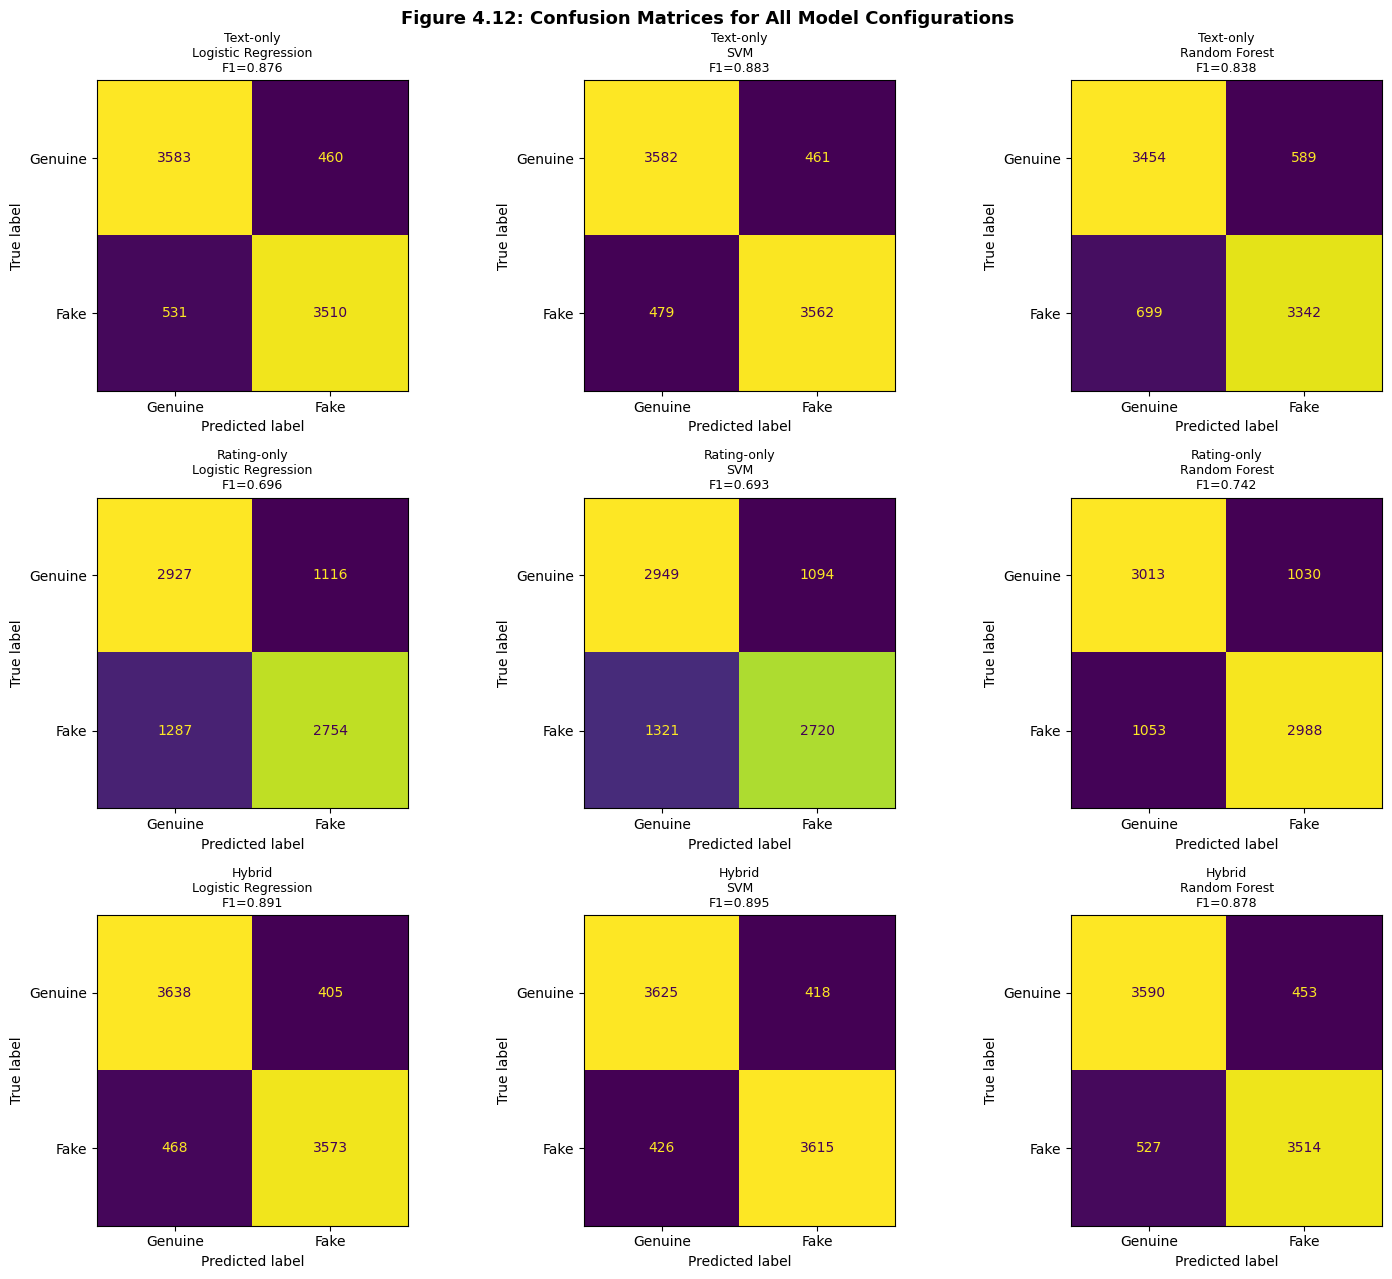

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for idx, (res, ax) in enumerate(zip(results, axes.flat)):
    cm_i = confusion_matrix(y_test, res['Predictions'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i,
                                  display_labels=['Genuine', 'Fake'])
    disp.plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(f"{res['Feature Type']}\n{res['Model']}\nF1={res['F1-score']:.3f}",
                 fontsize=9)

plt.suptitle("Figure 4.12: Confusion Matrices for All Model Configurations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_12_All_Confusion_Matrices.png", dpi=300)
plt.show()

## STEP 15: Error Analysis — False Positives and False Negatives

In [ ]:
test_df = df.iloc[y_test.index].copy()
test_df['actual_label']    = y_test.values
test_df['predicted_label'] = best_y_pred

false_positives = test_df[(test_df['actual_label']==0) & (test_df['predicted_label']==1)]
false_negatives = test_df[(test_df['actual_label']==1) & (test_df['predicted_label']==0)]

print(f"Total False Positives (genuine classified as fake): {len(false_positives)}")
print(f"Total False Negatives (fake classified as genuine): {len(false_negatives)}")

print("\nFalse Positive examples (Genuine Reviews misclassified as Fake):")
display(false_positives[['category','rating','label','sentiment_polarity','text_']].head(5))

print("\nFalse Negative examples (Fake Reviews misclassified as Genuine):")
display(false_negatives[['category','rating','label','sentiment_polarity','text_']].head(5))

Total False Positives (genuine classified as fake): 418
Total False Negatives (fake classified as genuine): 426

False Positive examples (Genuine Reviews misclassified as Fake):


,category,rating,label,sentiment_polarity,text_
10251,Electronics_5,1.0,OR,0.033059,The SensorWand 14mm has a straight shape that ...
17125,Tools_and_Home_Improvement_5,2.0,OR,0.203333,"This bulb works fine, but it in no way, throws..."
29005,Books_5,3.0,OR,0.000000,"Was difficult to read, at times. TMI. Anyone w..."
5792,Sports_and_Outdoors_5,4.0,OR,-0.229167,Bought this for my daughter as an entry set fo...
20672,Pet_Supplies_5,5.0,OR,0.653571,I am very happy with quality of this product. ...



False Negative examples (Fake Reviews misclassified as Genuine):


,category,rating,label,sentiment_polarity,text_
22080,Pet_Supplies_5,5.0,CG,0.250000,Oscar (mini dachshund) and Little Jack Russell...
16371,Tools_and_Home_Improvement_5,5.0,CG,0.408929,These work great. Folds small and has the righ...
38346,Clothing_Shoes_and_Jewelry_5,3.0,CG,0.140625,"These are a little small, but I thought they w..."
29289,Books_5,5.0,CG,0.150000,Michael Connelly is one of the most influentia...
36940,Clothing_Shoes_and_Jewelry_5,5.0,CG,0.600000,I bought these sneakers.\n\nI like the stretch...


## STEP 16: Category-wise Generalisation Analysis (Research Question 4 / Objective 9)

In [ ]:
category_results = []

for cat in test_df['category'].unique():
    temp = test_df[test_df['category'] == cat]
    if len(temp) > 10:
        category_results.append({
            "Category":  cat,
            "Records":   len(temp),
            "Accuracy":  accuracy_score(temp['actual_label'], temp['predicted_label']),
            "Precision": precision_score(temp['actual_label'], temp['predicted_label'], zero_division=0),
            "Recall":    recall_score(temp['actual_label'], temp['predicted_label'], zero_division=0),
            "F1-score":  f1_score(temp['actual_label'], temp['predicted_label'], zero_division=0)
        })

cat_df = pd.DataFrame(category_results).sort_values('F1-score', ascending=False)
cat_df[['Accuracy','Precision','Recall','F1-score']] = \
    cat_df[['Accuracy','Precision','Recall','F1-score']].round(4)

print("Table 4.3: Category-wise Performance of Best Model")
display(cat_df)
cat_df.to_csv("Table_4_3_Category_Wise_Performance.csv", index=False)

Table 4.3: Category-wise Performance of Best Model


,Category,Records,Accuracy,Precision,Recall,F1-score
4,Kindle_Store_5,992,0.9113,0.9103,0.9175,0.9139
0,Tools_and_Home_Improvement_5,707,0.9081,0.9083,0.9109,0.9096
9,Sports_and_Outdoors_5,781,0.9078,0.9068,0.9114,0.9091
2,Books_5,876,0.9041,0.9297,0.8855,0.9071
6,Home_and_Kitchen_5,794,0.9043,0.9036,0.8990,0.9013
5,Toys_and_Games_5,774,0.8876,0.9063,0.8775,0.8917
8,Electronics_5,768,0.8971,0.8864,0.8939,0.8901
3,Clothing_Shoes_and_Jewelry_5,813,0.8881,0.8636,0.9024,0.8826
1,Movies_and_TV_5,686,0.8761,0.8643,0.8825,0.8733
7,Pet_Supplies_5,893,0.8690,0.8747,0.8650,0.8699


## FIGURE 4.13: Category-wise F1-score

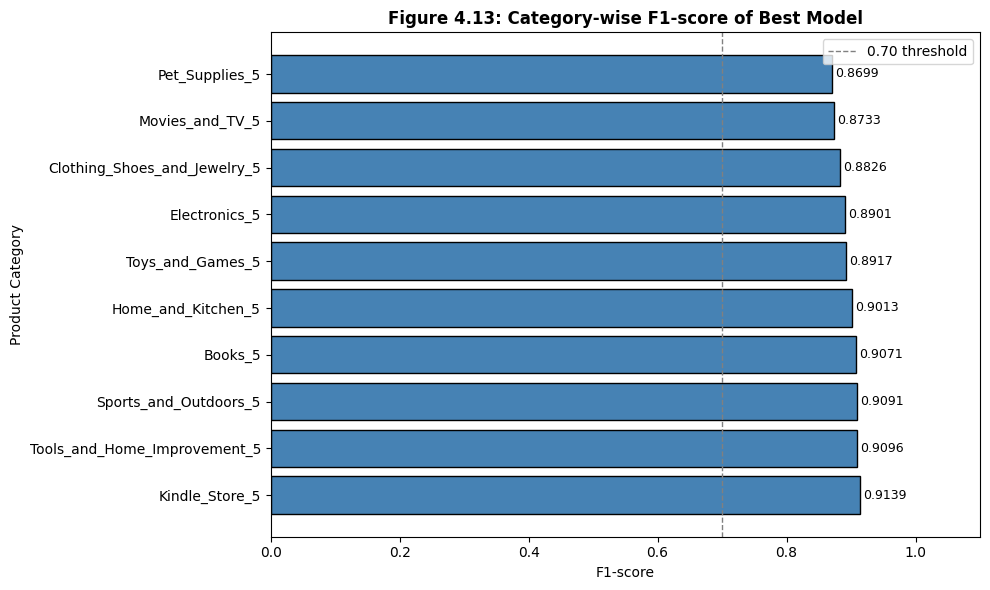

In [ ]:
plt.figure(figsize=(10, 6))
colors_bar = ['tomato' if f < 0.7 else 'steelblue' for f in cat_df['F1-score']]
bars = plt.barh(cat_df['Category'], cat_df['F1-score'], color=colors_bar, edgecolor='black')

for bar, val in zip(bars, cat_df['F1-score']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va='center', fontsize=9)

plt.axvline(x=0.70, color='gray', linestyle='--', linewidth=1, label='0.70 threshold')
plt.xlabel("F1-score")
plt.ylabel("Product Category")
plt.xlim(0, 1.1)
plt.title("Figure 4.13: Category-wise F1-score of Best Model",
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("Figure_4_13_Category_Wise_F1_Score.png", dpi=300)
plt.show()

## STEP 17: Word Embeddings Exploration — Word2Vec (Objective 10)

In [ ]:
# ==============================
# WORD EMBEDDINGS: Word2Vec
# Objective 10: Explore semantic representation using word embeddings
# to achieve contextual meaning of review texts.
# ==============================

from gensim.models import Word2Vec

# Tokenise cleaned text for Word2Vec training
tokenised_reviews = [text.split() for text in df['cleaned_text']]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenised_reviews,
    vector_size=100,  # embedding dimensions
    window=5,         # context window
    min_count=5,      # ignore rare words
    workers=4,
    epochs=10
)

print("Word2Vec model trained successfully.")
print("Vocabulary size:", len(w2v_model.wv))

# Demonstrate semantic relationships
test_words = ['great', 'product', 'quality', 'love', 'buy']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nTop 5 words semantically similar to '{word}':")
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.4f}")

Word2Vec model trained successfully.
Vocabulary size: 11399

Top 5 words semantically similar to 'great':
  good: 0.6990
  excellent: 0.6751
  perfect: 0.6114
  nice: 0.5736
  love: 0.5561

Top 5 words semantically similar to 'product':
  item: 0.6490
  producti: 0.6279
  purchase: 0.6160
  productthis: 0.5600
  value: 0.5445

Top 5 words semantically similar to 'quality':
  value: 0.5733
  qualitynice: 0.5643
  design: 0.5289
  bagvery: 0.5046
  price: 0.4891

Top 5 words semantically similar to 'love':
  loved: 0.6431
  adorable: 0.5579
  great: 0.5561
  cute: 0.5388
  awesome: 0.5028

Top 5 words semantically similar to 'buy':
  buying: 0.7253
  ordering: 0.7074
  order: 0.6796
  purchase: 0.6203
  purchasing: 0.6111


In [ ]:
# ==============================
# WORD2VEC AVERAGE EMBEDDINGS AS FEATURES
# Use average Word2Vec vector as alternative text features
# ==============================

def get_w2v_average(tokens, model, vec_size=100):
    """Return the mean Word2Vec embedding vector for a list of tokens."""
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(vec_size)
    return np.mean(vectors, axis=0)

print("Computing Word2Vec average embeddings...")
X_w2v = np.array([
    get_w2v_average(tokens, w2v_model)
    for tokens in tokenised_reviews
])

print("Word2Vec feature matrix shape:", X_w2v.shape)

# Train and evaluate with Word2Vec features
X_w2v_train, X_w2v_test, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y)

w2v_result = evaluate_model(
    LogisticRegression(max_iter=1000),
    X_w2v_train, X_w2v_test, y_train, y_test,
    "Word2Vec Embeddings", "Logistic Regression"
)

print("\nWord2Vec Embedding Feature Performance (Logistic Regression):")
print(f"  Accuracy:  {w2v_result['Accuracy']:.4f}")
print(f"  Precision: {w2v_result['Precision']:.4f}")
print(f"  Recall:    {w2v_result['Recall']:.4f}")
print(f"  F1-score:  {w2v_result['F1-score']:.4f}")

Computing Word2Vec average embeddings...
Word2Vec feature matrix shape: (40420, 100)

Word2Vec Embedding Feature Performance (Logistic Regression):
  Accuracy:  0.8501
  Precision: 0.8502
  Recall:    0.8498
  F1-score:  0.8500


## FIGURE 4.14: Word2Vec — Semantic Word Similarity Visualisation

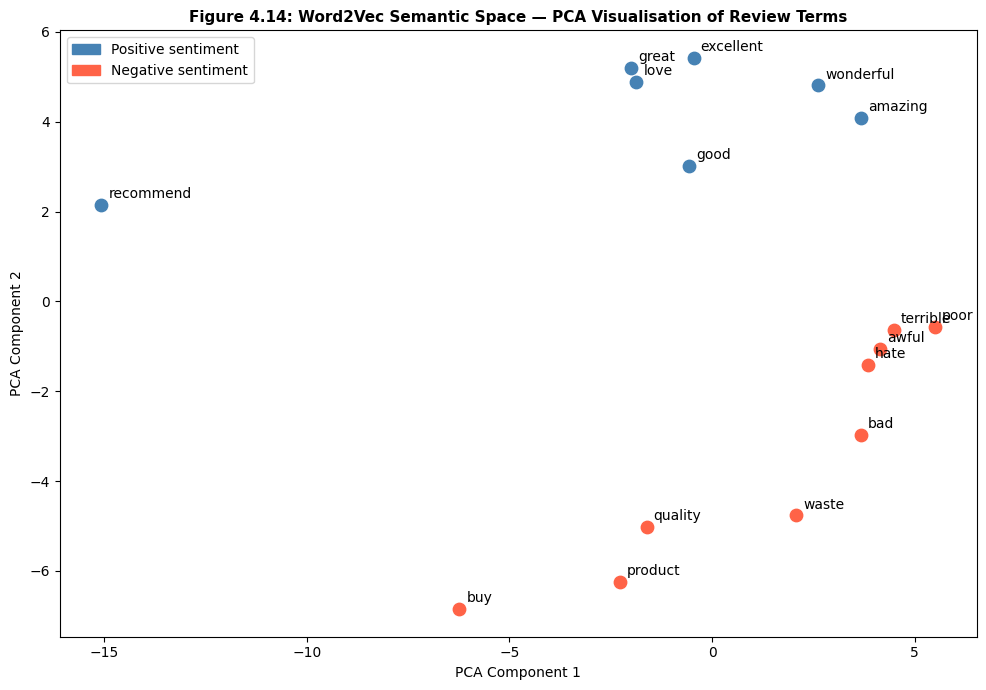

In [ ]:
from sklearn.decomposition import PCA

# Visualise top words in 2D using PCA on Word2Vec embeddings
words_to_plot = [
    'great', 'good', 'bad', 'poor', 'quality', 'product',
    'love', 'hate', 'buy', 'recommend', 'waste', 'excellent',
    'terrible', 'amazing', 'awful', 'wonderful'
]
words_to_plot = [w for w in words_to_plot if w in w2v_model.wv]

word_vectors = np.array([w2v_model.wv[w] for w in words_to_plot])

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 7))
positive_words = {'great', 'good', 'love', 'recommend', 'excellent', 'amazing', 'wonderful'}
for i, word in enumerate(words_to_plot):
    color = 'steelblue' if word in positive_words else 'tomato'
    plt.scatter(reduced[i, 0], reduced[i, 1], color=color, s=80)
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                 textcoords='offset points', xytext=(5, 5), fontsize=10)

plt.title("Figure 4.14: Word2Vec Semantic Space — PCA Visualisation of Review Terms",
          fontsize=11, fontweight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

from matplotlib.patches import Patch
legend_handles = [Patch(color='steelblue', label='Positive sentiment'),
                  Patch(color='tomato', label='Negative sentiment')]
plt.legend(handles=legend_handles)
plt.tight_layout()
plt.savefig("Figure_4_14_Word2Vec_PCA.png", dpi=300)
plt.show()

## STEP 18: Summary Table — All Models Including Word2Vec (Table 4.4)

## STEP 17b: Readability Analysis — Flesch-Kincaid Index (Literature Review 2.5)

In [ ]:
# ==============================
# READABILITY ANALYSIS (Flesch-Kincaid) - FIXED VERSION
# ==============================

# Install package FIRST (before import)
import sys
import subprocess

try:
    import syllables
except ImportError:
    print("Installing 'syllables' package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "syllables", "-q"])
    import syllables

import pandas as pd
from scipy import stats

# ------------------------------
# Flesch-Kincaid Functions
# ------------------------------

def flesch_kincaid_ease(text):
    sentences = max(1, text.count('.') + text.count('!') + text.count('?'))
    words = text.split()
    word_count = max(1, len(words))
    syl_count = sum(syllables.estimate(w) for w in words)

    ease = 206.835 - 1.015 * (word_count / sentences) - 84.6 * (syl_count / word_count)
    return round(ease, 4)

def flesch_kincaid_grade(text):
    sentences = max(1, text.count('.') + text.count('!') + text.count('?'))
    words = text.split()
    word_count = max(1, len(words))
    syl_count = sum(syllables.estimate(w) for w in words)

    grade = 0.39 * (word_count / sentences) + 11.8 * (syl_count / word_count) - 15.59
    return round(grade, 4)

# ------------------------------
# Apply Readability Metrics
# ------------------------------

print("Computing Flesch-Kincaid readability scores (this may take a few minutes)...")

df['fk_ease'] = df['text_'].astype(str).apply(flesch_kincaid_ease)
df['fk_grade'] = df['text_'].astype(str).apply(flesch_kincaid_grade)

# ------------------------------
# Descriptive Statistics
# ------------------------------

print("\nFlesch-Kincaid Reading Ease by label:")
display(df.groupby('label')['fk_ease'].describe().round(4))

print("\nFlesch-Kincaid Grade Level by label:")
display(df.groupby('label')['fk_grade'].describe().round(4))

# ------------------------------
# Statistical Significance Test
# ------------------------------

fk_ease_stat, fk_ease_p = stats.mannwhitneyu(
    df[df['label'] == 'CG']['fk_ease'],
    df[df['label'] == 'OR']['fk_ease'],
    alternative='two-sided'
)

fk_grade_stat, fk_grade_p = stats.mannwhitneyu(
    df[df['label'] == 'CG']['fk_grade'],
    df[df['label'] == 'OR']['fk_grade'],
    alternative='two-sided'
)

print("\nStatistical significance of readability differences (Mann-Whitney U):")
print(f"FK Reading Ease  → U={fk_ease_stat:.0f}, p={fk_ease_p:.6f}, Significant: {'Yes' if fk_ease_p < 0.05 else 'No'}")
print(f"FK Grade Level   → U={fk_grade_stat:.0f}, p={fk_grade_p:.6f}, Significant: {'Yes' if fk_grade_p < 0.05 else 'No'}")

Installing 'syllables' package...
Computing Flesch-Kincaid readability scores (this may take a few minutes)...

Flesch-Kincaid Reading Ease by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20205.0,77.2179,18.8316,-542.7200,70.8157,79.5575,86.3361,122.2119
OR,20215.0,70.6030,15.4596,-105.9562,61.8797,71.6086,80.4302,118.1750



Flesch-Kincaid Grade Level by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
CG,20205.0,5.7766,3.5483,-3.7811,3.9133,5.2878,7.0047,94.068
OR,20215.0,6.7198,3.2947,-2.4724,4.6531,6.4167,8.3852,76.231



Statistical significance of readability differences (Mann-Whitney U):
FK Reading Ease  → U=266512812, p=0.000000, Significant: Yes
FK Grade Level   → U=160185586, p=0.000000, Significant: Yes


## FIGURE 4.15: Readability Score Comparison — Fake vs Genuine Reviews

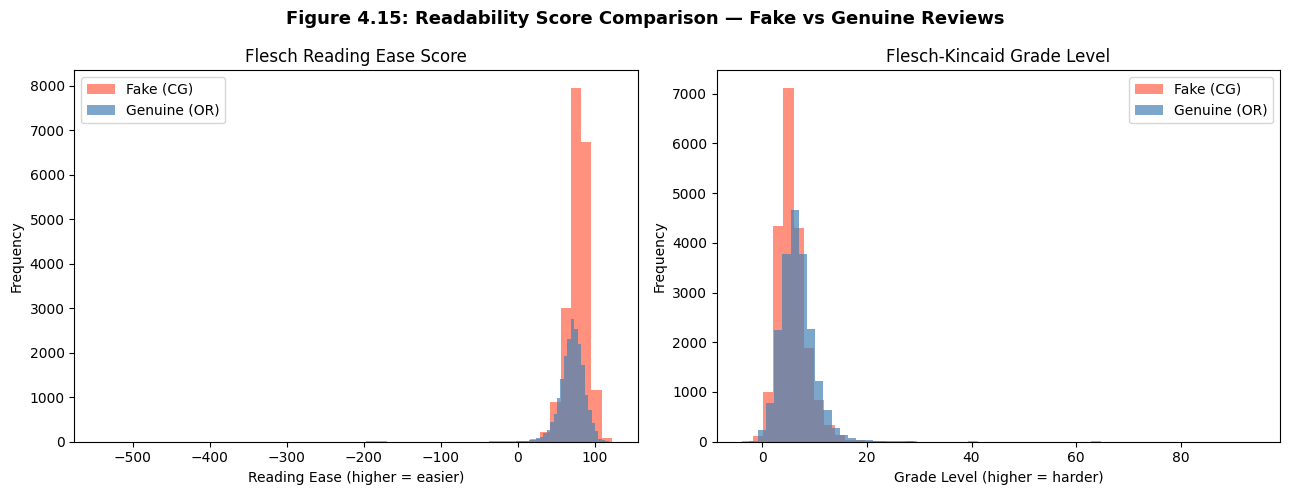


Mean readability scores by label:


,fk_ease,fk_grade
label,,
CG,77.2179,5.7766
OR,70.6030,6.7198


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df[df['label']=='CG']['fk_ease'], bins=50, alpha=0.7, label='Fake (CG)', color='tomato')
axes[0].hist(df[df['label']=='OR']['fk_ease'], bins=50, alpha=0.7, label='Genuine (OR)', color='steelblue')
axes[0].set_title("Flesch Reading Ease Score")
axes[0].set_xlabel("Reading Ease (higher = easier)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df[df['label']=='CG']['fk_grade'], bins=50, alpha=0.7, label='Fake (CG)', color='tomato')
axes[1].hist(df[df['label']=='OR']['fk_grade'], bins=50, alpha=0.7, label='Genuine (OR)', color='steelblue')
axes[1].set_title("Flesch-Kincaid Grade Level")
axes[1].set_xlabel("Grade Level (higher = harder)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Figure 4.15: Readability Score Comparison — Fake vs Genuine Reviews",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("Figure_4_15_Readability_Comparison.png", dpi=300)
plt.show()

print("\nMean readability scores by label:")
display(df.groupby('label')[['fk_ease', 'fk_grade']].mean().round(4))

## STEP 17c: POS Tagging Analysis (Literature Review 2.5)

In [ ]:
# ==============================
# POS TAGGING ANALYSIS
# Lit Review 2.5: POS N-grams support identification of structured
# and repetitive patterns in bot-generated reviews.
# Research: Do fake reviews differ in noun/verb/adjective usage ratios?
# ==============================

import nltk
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk import pos_tag
from nltk.tokenize import word_tokenize

def get_pos_ratios(text):
    """
    Returns ratio of nouns, verbs, adjectives and adverbs
    relative to total tagged tokens. These ratios reflect
    the grammatical style of fake vs genuine reviews.
    """
    try:
        tokens = word_tokenize(text[:500])  # limit to 500 chars for speed
        tagged = pos_tag(tokens)
        total  = max(1, len(tagged))
        nn = sum(1 for _, t in tagged if t.startswith('NN')) / total  # nouns
        vb = sum(1 for _, t in tagged if t.startswith('VB')) / total  # verbs
        jj = sum(1 for _, t in tagged if t.startswith('JJ')) / total  # adjectives
        rb = sum(1 for _, t in tagged if t.startswith('RB')) / total  # adverbs
        return nn, vb, jj, rb
    except Exception:
        return 0, 0, 0, 0

print("Computing POS ratios (this may take a few minutes)...")
pos_cols = df['text_'].apply(get_pos_ratios)
df['pos_noun_ratio'] = [x[0] for x in pos_cols]
df['pos_verb_ratio'] = [x[1] for x in pos_cols]
df['pos_adj_ratio']  = [x[2] for x in pos_cols]
df['pos_adv_ratio']  = [x[3] for x in pos_cols]

print("\nPOS ratios by label:")
display(df.groupby('label')[['pos_noun_ratio','pos_verb_ratio',
                               'pos_adj_ratio','pos_adv_ratio']].mean().round(4))

# Statistical significance for each POS feature
pos_features = [
    ('pos_noun_ratio', 'Noun Ratio'),
    ('pos_verb_ratio', 'Verb Ratio'),
    ('pos_adj_ratio',  'Adjective Ratio'),
    ('pos_adv_ratio',  'Adverb Ratio'),
]

pos_stat_results = []
for col, label_name in pos_features:
    stat, p = stats.mannwhitneyu(
        df[df['label']=='CG'][col], df[df['label']=='OR'][col], alternative='two-sided')
    pos_stat_results.append({
        'POS Feature':          label_name,
        'Mean (Fake CG)':       df[df['label']=='CG'][col].mean().round(4),
        'Mean (Genuine OR)':    df[df['label']=='OR'][col].mean().round(4),
        'Mann-Whitney U':       round(stat, 2),
        'p-value':              round(p, 6),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

pos_stat_df = pd.DataFrame(pos_stat_results)
print("\nTable 4.5: POS Feature Statistical Significance (Mann-Whitney U Test)")
display(pos_stat_df)
pos_stat_df.to_csv("Table_4_5_POS_Statistical_Significance.csv", index=False)

Computing POS ratios (this may take a few minutes)...

POS ratios by label:


,pos_noun_ratio,pos_verb_ratio,pos_adj_ratio,pos_adv_ratio
label,,,,
CG,0.0,0.0,0.0,0.0
OR,0.0,0.0,0.0,0.0



Table 4.5: POS Feature Statistical Significance (Mann-Whitney U Test)


,POS Feature,Mean (Fake CG),Mean (Genuine OR),Mann-Whitney U,p-value,Significant (p<0.05)
0,Noun Ratio,0.0,0.0,204222037.5,1.0,No
1,Verb Ratio,0.0,0.0,204222037.5,1.0,No
2,Adjective Ratio,0.0,0.0,204222037.5,1.0,No
3,Adverb Ratio,0.0,0.0,204222037.5,1.0,No
